# Multi-Location Stage 1-4 Diagnostic Mosaics

## Objective

For the ZA-GAS pipeline's Stages 1-4 (Stage 1 baseline GAS, Stage 2
weather covariates, Stage 3 Harvey long-short, Stage 4 tail-sensitive
$\xi$ regime), this notebook builds **7 mosaic figures** showing each
stage's own winning model at every one of the six completed locations
(Belo Horizonte, Cruzeiro do Sul, Darwin Airport, Garanhuns, Manaus,
Salvador), side by side:

- **3 Stages 1-3 grids per branch** (rows = stage 1/2/3, columns =
  location) — one grid for the PIT histogram, one for the normal QQ plot,
  one for the 400-lag quantile-residual ACF. Produced once for the
  **phi+xi branch** and once for the **phi-only branch** (6 figures
  total), so scanning down a column shows how one location's calibration
  evolves from Stage 1 through Stage 3.
- **1 Stage 4 composite grid** (rows = location, columns = PIT / QQ / ACF)
  — Stage 4 has no branch split, so all three chart types live in a
  single figure instead.

"That stage's own winner" means exactly what `stage_winners.json` recorded
as the best model **at that stage**, independent of whether it went on to
become the pipeline's overall final model — so, for example, the Stage 1
row always shows Stage 1's own best baseline GAS specification, even at
locations where a later stage's model ended up beating it overall.

Stages 1-3 track two parallel branches (see `docs/MODELS.md` Sec 27 and
`run_all_locations.py`'s module docstring): a **phi+xi branch** (dynamic
scale and tail shape, ranked by CRPS — the primary distributional
objective) and a **phi-only branch** (dynamic scale only, ranked by RMSE —
the point-forecast objective). Stage 4 (the tail-sensitive $\xi$ regime
model) is diagnosed on its own, at whichever threshold ($q_{95}$ or
$q_{98}$) performed relatively better, whether or not Stage 4 was
ultimately accepted at that location (a rejected regime model's
calibration is still informative).

All diagnostics shown here are **in-sample (IS)** — computed from the
training-period predictive CDF evaluated at the training observations, per
`docs/REPORTING.md` Sec 11 ("clearly separate In-Sample and Out-of-Sample
results").

Everything is computed from saved artifacts only — **no model is
re-estimated** (`docs/EXECUTION.md` Sec 22: "Reports should never call
optimization").

Outputs are written to `reports/multi_location/mosaics/`.


## Mathematical Background

### Quantile residuals and PIT

Let $F_t(\cdot)$ denote the one-step-ahead predictive CDF implied by a
fitted model at time $t$, and $y_t$ the observed precipitation. The
Probability Integral Transform (PIT) value is

$$
u_t = F_t(y_t),
$$

and the quantile residual (Dunn & Smyth, 1996) is

$$
r_t = \Phi^{-1}(u_t),
$$

where $\Phi^{-1}$ is the standard normal quantile function. Under a
correctly specified model, $u_t \sim \text{iid Uniform}(0,1)$ and
$r_t \sim \text{iid } N(0,1)$.

Because the zero-augmented model has a probability mass at $y_t = 0$
(occurrence probability $\pi_t$; see `docs/MODELS.md` Sec 3), $F_t$ jumps
at zero and the PIT is *randomised* there: for $y_t = 0$,
$u_t \sim \text{Uniform}(0, F_t(0))$, while for $y_t > 0$, $u_t = F_t(y_t)$
exactly (see `diagnostics/residuals.py` for the full derivation). This
notebook always uses the randomised version, matching the rest of the
report pipeline.

### PIT histogram

A histogram of $\{u_t\}$ should be approximately flat at height 1 (the
Uniform(0,1) density, shown as a red dashed reference line in every
panel). A U-shape indicates the model is under-dispersed (its predictive
intervals are too narrow); a hump indicates over-dispersion; skew
indicates systematic over- or under-prediction.

### Normal QQ plot

Sorted sample quantile residuals are plotted against their theoretical
$N(0,1)$ quantiles (plotting positions $\Phi^{-1}((i-0.5)/n)$). Points
should fall on the $y = x$ reference line. Departures at the extremes of
the line are the most scientifically important failure mode for this
project (`docs/MODELS.md` Sec 27: "point forecasting is secondary to
distributional and tail performance") — they reveal poor tail calibration
even when bulk calibration looks fine.

### Residual ACF and its confidence band

The sample autocorrelation of $\{r_t\}$ at lag $k$,

$$
\hat\rho_k = \frac{\sum_{t=k+1}^{n}(r_t-\bar r)(r_{t-k}-\bar r)}{\sum_{t=1}^{n}(r_t-\bar r)^2},
$$

is computed for $k = 1, \dots, 400$ (lag 0 is always 1 by construction and
is excluded, per `docs/REPORTING.md` Sec 13). Under the null hypothesis of
no residual autocorrelation, $\hat\rho_k$ is asymptotically $N(0, 1/n)$
(Bartlett's approximation for a white-noise series), so a two-sided 95%
band is

$$
\hat\rho_k \in \left[-\frac{1.96}{\sqrt{n}},\ \frac{1.96}{\sqrt{n}}\right] \approx \pm\frac{2}{\sqrt{n}},
$$

shown as the shaded red band in every ACF panel, **recomputed per panel
from that location's own effective sample size $n$** (warm-up length and
covariate-driven trimming differ across models). Bars extending outside
the band suggest the model has not fully absorbed some structure in the
series (most commonly residual seasonality near lag $\approx 365$).


In [1]:
# =============================================================================
# Imports and project-root path setup
# =============================================================================
# This notebook ORCHESTRATES only -- per docs/EXECUTION.md Sec 23
# ("Notebooks should orchestrate experiments ... They should not contain
# model implementations"), every non-trivial computation (model
# reconstruction, PIT/quantile-residual computation, mosaic figure
# construction) lives in reusable modules:
#     diagnostics/multilocation_mosaics.py  -- which model is "the winner"
#     diagnostics/plots.py                  -- what the mosaics look like
# This notebook just calls them in the right order and saves the results.

from __future__ import annotations

import sys
from pathlib import Path

import pandas as pd
import matplotlib
matplotlib.use("Agg")  # headless rendering -- figures are displayed below
                        # via explicit fig.savefig() + IPython Image, not
                        # matplotlib's interactive/inline backend, so this
                        # notebook renders identically whether run inside
                        # Jupyter or from the command line (nbconvert).
import matplotlib.pyplot as plt
from IPython.display import Image, display

# Project root = the directory this notebook lives in.
ROOT = Path.cwd()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from diagnostics.multilocation_mosaics import (
    LOCATIONS, STAGE_LABELS, BRANCH_LABELS, ARTIFACTS_DIR,
    resolve_stage_winner, load_all_location_data,
    compute_stage_branch_diagnostics, compute_stages_1to3_grid,
)
from diagnostics.plots import (
    stage_pit_grid_mosaic, stage_qq_grid_mosaic, stage_acf_grid_mosaic,
    stage4_composite_mosaic,
)
from data.station_loader import STATION_REGISTRY, mosaic_name

print("Locations:", LOCATIONS)
print("Stages:   ", STAGE_LABELS)

Locations: ['BELO HORIZONTE', 'CRUZEIRO DO SUL (ACRE)', 'DARWIN AIRPORT', 'GARANHUNS (PERNAMBUCO)', 'MANAUS', 'SALVADOR']
Stages:    {1: 'Stage 1 -- Baseline GAS', 2: 'Stage 2 -- Weather Covariates', 3: 'Stage 3 -- Harvey Long-Short', 4: 'Stage 4 -- Tail-Sensitive xi Regime'}


In [2]:
# =============================================================================
# Configuration
# =============================================================================
# Per user instruction: plot each stage's own winner "regardless of
# whether that stage's model won the overall pipeline comparison" -- i.e.
# always show Stage 1's own best baseline GAS, Stage 2's own best
# weather-covariate model, etc., not just whichever stage produced the
# pipeline's final selected model.
#
# Stages 1-3 track two independent branches through the whole pipeline
# (docs/MODELS.md Sec 27; run_all_locations.py module docstring): "phi_xi"
# (dynamic xi, ranked by CRPS -- the scientifically primary distributional
# branch) and "phi_only" (phi dynamic only, ranked by RMSE -- the
# point-forecast branch). Each branch gets its own Stages-1-3 grid mosaic
# per chart type. Stage 4 has no branch split (see
# diagnostics/multilocation_mosaics.py's resolve_stage4_winner), so it is
# handled separately as one composite mosaic.
STAGES_1TO3 = [1, 2, 3]
BRANCHES    = ["phi_xi", "phi_only"]

# Column order for every grid mosaic -- location *display* names, in the
# same order as diagnostics.multilocation_mosaics.LOCATIONS.
LOCATION_DISPLAY_NAMES = [STATION_REGISTRY[s]["display"] for s in LOCATIONS]

# Per-location row-label overrides, keyed by the *display* name (i.e. the
# same strings as LOCATION_DISPLAY_NAMES) so nothing about how figures are
# looked up needs to change:
#   LOCATION_NAMES     -- text actually drawn as the row label. Only Darwin
#                          Airport differs from its own "display" name
#                          (data/station_loader.py's mosaic_name()); every
#                          other location's row label is unchanged.
#   LOCATION_COUNTRIES -- "(Country)" subtitle drawn alongside the name
#                          (diagnostics/plots.py's _row_label), from the
#                          new "country" field in STATION_REGISTRY.
LOCATION_NAMES     = {STATION_REGISTRY[s]["display"]: mosaic_name(s) for s in LOCATIONS}
LOCATION_COUNTRIES = {STATION_REGISTRY[s]["display"]: f"({STATION_REGISTRY[s]['country']})" for s in LOCATIONS}

# Short row labels for the Stages-1-3 grids (the mosaic already carries
# the full stage description in its suptitle, so row labels stay compact).
STAGE_ROW_LABELS = {stage: f"Stage {stage}" for stage in STAGES_1TO3}

# Output locations. "reports/multi_location" already holds the main
# multi-location report (report.tex/.pdf, per-model figures); these
# mosaics live in a clearly separated subfolder so they never collide with
# or overwrite that report's own artifacts.
REPORTS_DIR   = ROOT / "reports" / "multi_location"
MOSAICS_DIR   = REPORTS_DIR / "mosaics"
TABLES_DIR    = MOSAICS_DIR / "tables"
FIG_CACHE_DIR = MOSAICS_DIR / "_individual_model_cache"
# ^ per-model PNGs that _compute_is_diagnostics_for_winner always saves as
#   a side effect (one PIT + one QQ + one ACF per model, not the mosaics
#   themselves) -- kept isolated from reports/multi_location/figures/, the
#   main report's own cache, so this notebook never overwrites it.

MOSAICS_DIR.mkdir(parents=True, exist_ok=True)
TABLES_DIR.mkdir(parents=True, exist_ok=True)
FIG_CACHE_DIR.mkdir(parents=True, exist_ok=True)

# ---------------------------------------------------------------------------
# Design knobs -- see diagnostics/plots.py docstrings for what each
# parameter controls. Change these to restyle every mosaic without
# touching the orchestration logic in the cells below. Grid *shape* itself
# (rows/columns) is fixed by STAGES_1TO3 x LOCATION_DISPLAY_NAMES (or
# LOCATION_DISPLAY_NAMES x chart type for Stage 4), not a free ncols knob
# -- each row/column has a specific stage or location meaning now, so it
# is no longer just "however many columns look nice".
# ---------------------------------------------------------------------------
ACF_N_LAGS = 400  # per docs/REPORTING.md Sec 13 ("Residual ACF should use 400 lags")
PIT_BINS   = 20

DPI = 150  # matches generate_report_extended.py's per-model figure resolution

print("Mosaics will be written to:", MOSAICS_DIR)
print("Location row labels:", LOCATION_NAMES)
print("Location countries: ", LOCATION_COUNTRIES)

Mosaics will be written to: C:\Users\ilang\OneDrive\Documentos\Ilan\academia\dissertação\python attempt\FurtherTopics\reports\multi_location\mosaics
Location row labels: {'Belo Horizonte': 'Belo Horizonte', 'Cruzeiro do Sul': 'Cruzeiro do Sul', 'Darwin Airport': 'Darwin', 'Garanhuns': 'Garanhuns', 'Manaus': 'Manaus', 'Salvador': 'Salvador'}
Location countries:  {'Belo Horizonte': '(Brazil)', 'Cruzeiro do Sul': '(Brazil)', 'Darwin Airport': '(Australia)', 'Garanhuns': '(Brazil)', 'Manaus': '(Brazil)', 'Salvador': '(Brazil)'}


## Figure design settings — EDIT HERE for font size / readability

**This is the one cell to change if the text in the mosaics looks too
small (or too big) once placed in the LaTeX dissertation.** No other cell
in this notebook needs to change for that.

Why a dedicated cell for this, instead of just "bigger numbers": these
mosaics are drawn many inches wide on screen (a 6-location × 3-stage ACF
grid is ~22in wide) so each individual panel has room to be legible. But
LaTeX then shrinks the whole figure down to whatever width it is placed
at on the page. A matplotlib "12pt" font shrinks by that same factor — if
the figure gets scaled down to 40% of its matplotlib size, a 12pt font
prints at ~5pt. Raising the matplotlib number blindly doesn't fix this
predictably, because the right number depends on how wide the figure ends
up being, which depends on how many locations/stages are in it.

The fix used here: `BASE_PRINT_PT` says what point size should actually
appear **on the printed page**, and every mosaic function (in
`diagnostics/plots.py`) works backwards from that to the matplotlib
fontsize it needs, given its own actual figure width and
`TARGET_PRINT_WIDTH_IN` (how wide the figure is placed in the document).

- `BASE_PRINT_PT["axis_label"] = 12` is calibrated to **this
  dissertation's own body text**: running `pdffonts` on
  `delivery/dissertação v2 072026/*.pdf` shows the body font is
  `LMRoman12`, i.e. 12pt Latin Modern Roman. If a future draft changes the
  base font size, update this to match.
- `TARGET_PRINT_WIDTH_IN` assumes these wide multi-panel grids are placed
  as a **full landscape page** (`\begin{sidewaysfigure}`), not squeezed
  into a portrait `\textwidth` column — ~9.5in is a typical A4 landscape
  page width after margins. **If you place a figure at a different
  width, change this number to match** (e.g. `6.3` for a normal portrait
  `\textwidth` figure), and every font in that figure rescales together
  to keep printing at the sizes below.


In [3]:
# =============================================================================
# FIGURE DESIGN SETTINGS -- font size / print-scale calibration
# =============================================================================
# See the markdown cell above for why this works the way it does. These
# two variables are passed as target_print_width_in= / base_print_pt=
# into every stage_*_grid_mosaic() / stage4_composite_mosaic() call below
# -- diagnostics/plots.py's own TARGET_PRINT_WIDTH_IN / BASE_PRINT_PT are
# only the fallback defaults used if you call those functions directly
# without overriding them, so editing the copies here is enough; you do
# not need to also edit diagnostics/plots.py.

# How wide (inches) the mosaic will actually be printed in the LaTeX
# document. Default assumes a full landscape page (\sidewaysfigure).
TARGET_PRINT_WIDTH_IN = 9.5

# Point sizes as they should appear ON THE PRINTED PAGE, calibrated to
# this dissertation's 12pt Latin Modern Roman body text (see markdown
# cell above). Raise/lower any of these independently.
BASE_PRINT_PT = {
    "suptitle":   20.0,  # figure title
    "header":     16.0,  # column headers (stage names, or chart-type names)
    "row_label":  13.0,  # row labels (location names) -- kept smaller than
                         # "header": rotated 90 deg and constrained by row
                         # *height*, not column width, so a long location
                         # name at "header" size can bleed into the row
                         # above/below it. If a row label still looks
                         # cramped for a very long location name, lower
                         # this rather than raising it.
    "axis_label": 12.0,  # x/y axis labels -- matches the dissertation body text
    "tick":       11.0,  # tick labels
    "legend":     11.0,  # legend text ("Uniform(0,1)", "y=x", null band)
    "annotation": 10.0,  # in-panel "n=..." text and "not run" placeholder text
}

print(f"Target print width: {TARGET_PRINT_WIDTH_IN} in")
print("Base print point sizes:", BASE_PRINT_PT)


Target print width: 9.5 in
Base print point sizes: {'suptitle': 20.0, 'header': 16.0, 'row_label': 13.0, 'axis_label': 12.0, 'tick': 11.0, 'legend': 11.0, 'annotation': 10.0}


In [4]:
# =============================================================================
# Load each location's data once
# =============================================================================
# Reused across every stage/branch combination below -- CSV/ERA5/ENSO
# source files are only read once per location per notebook run
# (docs/ARCHITECTURE.md Sec 11: "Reuse previously computed quantities
# whenever possible").
print("Loading data for all locations (precipitation, ERA5 dew point/")
print("temperature, and ENSO source files) -- may take a little while...")
location_data = load_all_location_data()
print(f"Loaded {len(location_data)} locations: {list(location_data.keys())}")


Loading data for all locations (precipitation, ERA5 dew point/
temperature, and ENSO source files) -- may take a little while...


Loaded 6 locations: ['BELO HORIZONTE', 'CRUZEIRO DO SUL (ACRE)', 'DARWIN AIRPORT', 'GARANHUNS (PERNAMBUCO)', 'MANAUS', 'SALVADOR']


In [5]:
# =============================================================================
# Resolve and record every stage/branch winner before plotting anything
# =============================================================================
# This table is the single source of truth for "which saved model_id is
# 'the best alternative' at this stage" -- every mosaic panel built below
# is a diagnostic of exactly one of these model_ids. Saved as CSV so the
# mapping is auditable independently of the figures themselves
# (docs/REPORTING.md Sec 26.4: "never allow manually entered numerical
# results").
from generate_report_extended import _load_winners

winner_rows = []
for stage in STAGES_1TO3:
    for branch in BRANCHES:
        for station in LOCATIONS:
            cfg = STATION_REGISTRY[station]
            run_dir = ARTIFACTS_DIR / cfg["run_id"]
            winners = _load_winners(run_dir) if run_dir.exists() else {}
            model_id = resolve_stage_winner(winners, stage, branch)
            winner_rows.append({
                "stage":       stage,
                "stage_label": STAGE_LABELS[stage],
                "branch":      branch,
                "location":    cfg["display"],
                "model_id":    model_id if model_id else "(not run / not available)",
            })

# Stage 4 has no branch split.
for station in LOCATIONS:
    cfg = STATION_REGISTRY[station]
    run_dir = ARTIFACTS_DIR / cfg["run_id"]
    winners = _load_winners(run_dir) if run_dir.exists() else {}
    model_id = resolve_stage_winner(winners, 4, None)
    winner_rows.append({
        "stage":       4,
        "stage_label": STAGE_LABELS[4],
        "branch":      "n/a",
        "location":    cfg["display"],
        "model_id":    model_id if model_id else "(not run / not available)",
    })

winner_table = pd.DataFrame(winner_rows)
winner_table.to_csv(TABLES_DIR / "stage_branch_winners.csv", index=False)
winner_table


,stage,stage_label,branch,location,model_id
0,1,Stage 1 -- Baseline GAS,phi_xi,Belo Horizonte,stage1_phixi_short_diagfi
1,1,Stage 1 -- Baseline GAS,phi_xi,Cruzeiro do Sul,stage1_phixi_short_diagfi
2,1,Stage 1 -- Baseline GAS,phi_xi,Darwin Airport,stage1_phixi_short_diagfi
3,1,Stage 1 -- Baseline GAS,phi_xi,Garanhuns,stage1_phixi_short_diagfi
4,1,Stage 1 -- Baseline GAS,phi_xi,Manaus,stage1_phixi_short_diagfi
5,1,Stage 1 -- Baseline GAS,phi_xi,Salvador,stage1_phixi_short_diagfi
6,1,Stage 1 -- Baseline GAS,phi_only,Belo Horizonte,stage1_phi_short_diagfi
7,1,Stage 1 -- Baseline GAS,phi_only,Cruzeiro do Sul,stage1_phi_short_diagfi
8,1,Stage 1 -- Baseline GAS,phi_only,Darwin Airport,stage1_phi_short_diagfi
9,1,Stage 1 -- Baseline GAS,phi_only,Garanhuns,stage1_phi_short_diagfi


In [6]:
# =============================================================================
# Naming and saving helpers
# =============================================================================

def stage1to3_slug(chart: str, branch: str) -> str:
    """Suggestive filename stem, e.g. 'stage1to3_acf400_phi_xi'."""
    return f"stage1to3_{chart}_{branch}"


def stage1to3_title(chart_name: str, branch: str) -> str:
    """Figure suptitle, e.g.
    'Stages 1-3 -- phi+xi branch -- In-sample normal QQ plots'."""
    return f"Stages 1-3 -- {BRANCH_LABELS[branch]} -- In-sample {chart_name}"


def save_mosaic(fig: "plt.Figure", stem: str) -> Path:
    """Save a mosaic Figure as both PNG (quick viewing) and PDF (vector,
    for LaTeX embedding per docs/REPORTING.md Sec 26.12: "figures as PDF
    and PNG"), close it to free memory, then display the PNG inline."""
    png_path = MOSAICS_DIR / f"{stem}.png"
    pdf_path = MOSAICS_DIR / f"{stem}.pdf"
    fig.savefig(png_path, dpi=DPI, bbox_inches="tight")
    fig.savefig(pdf_path, bbox_inches="tight")
    plt.close(fig)
    display(Image(filename=str(png_path)))
    return png_path



Stages 1-3 -- phi+xi branch


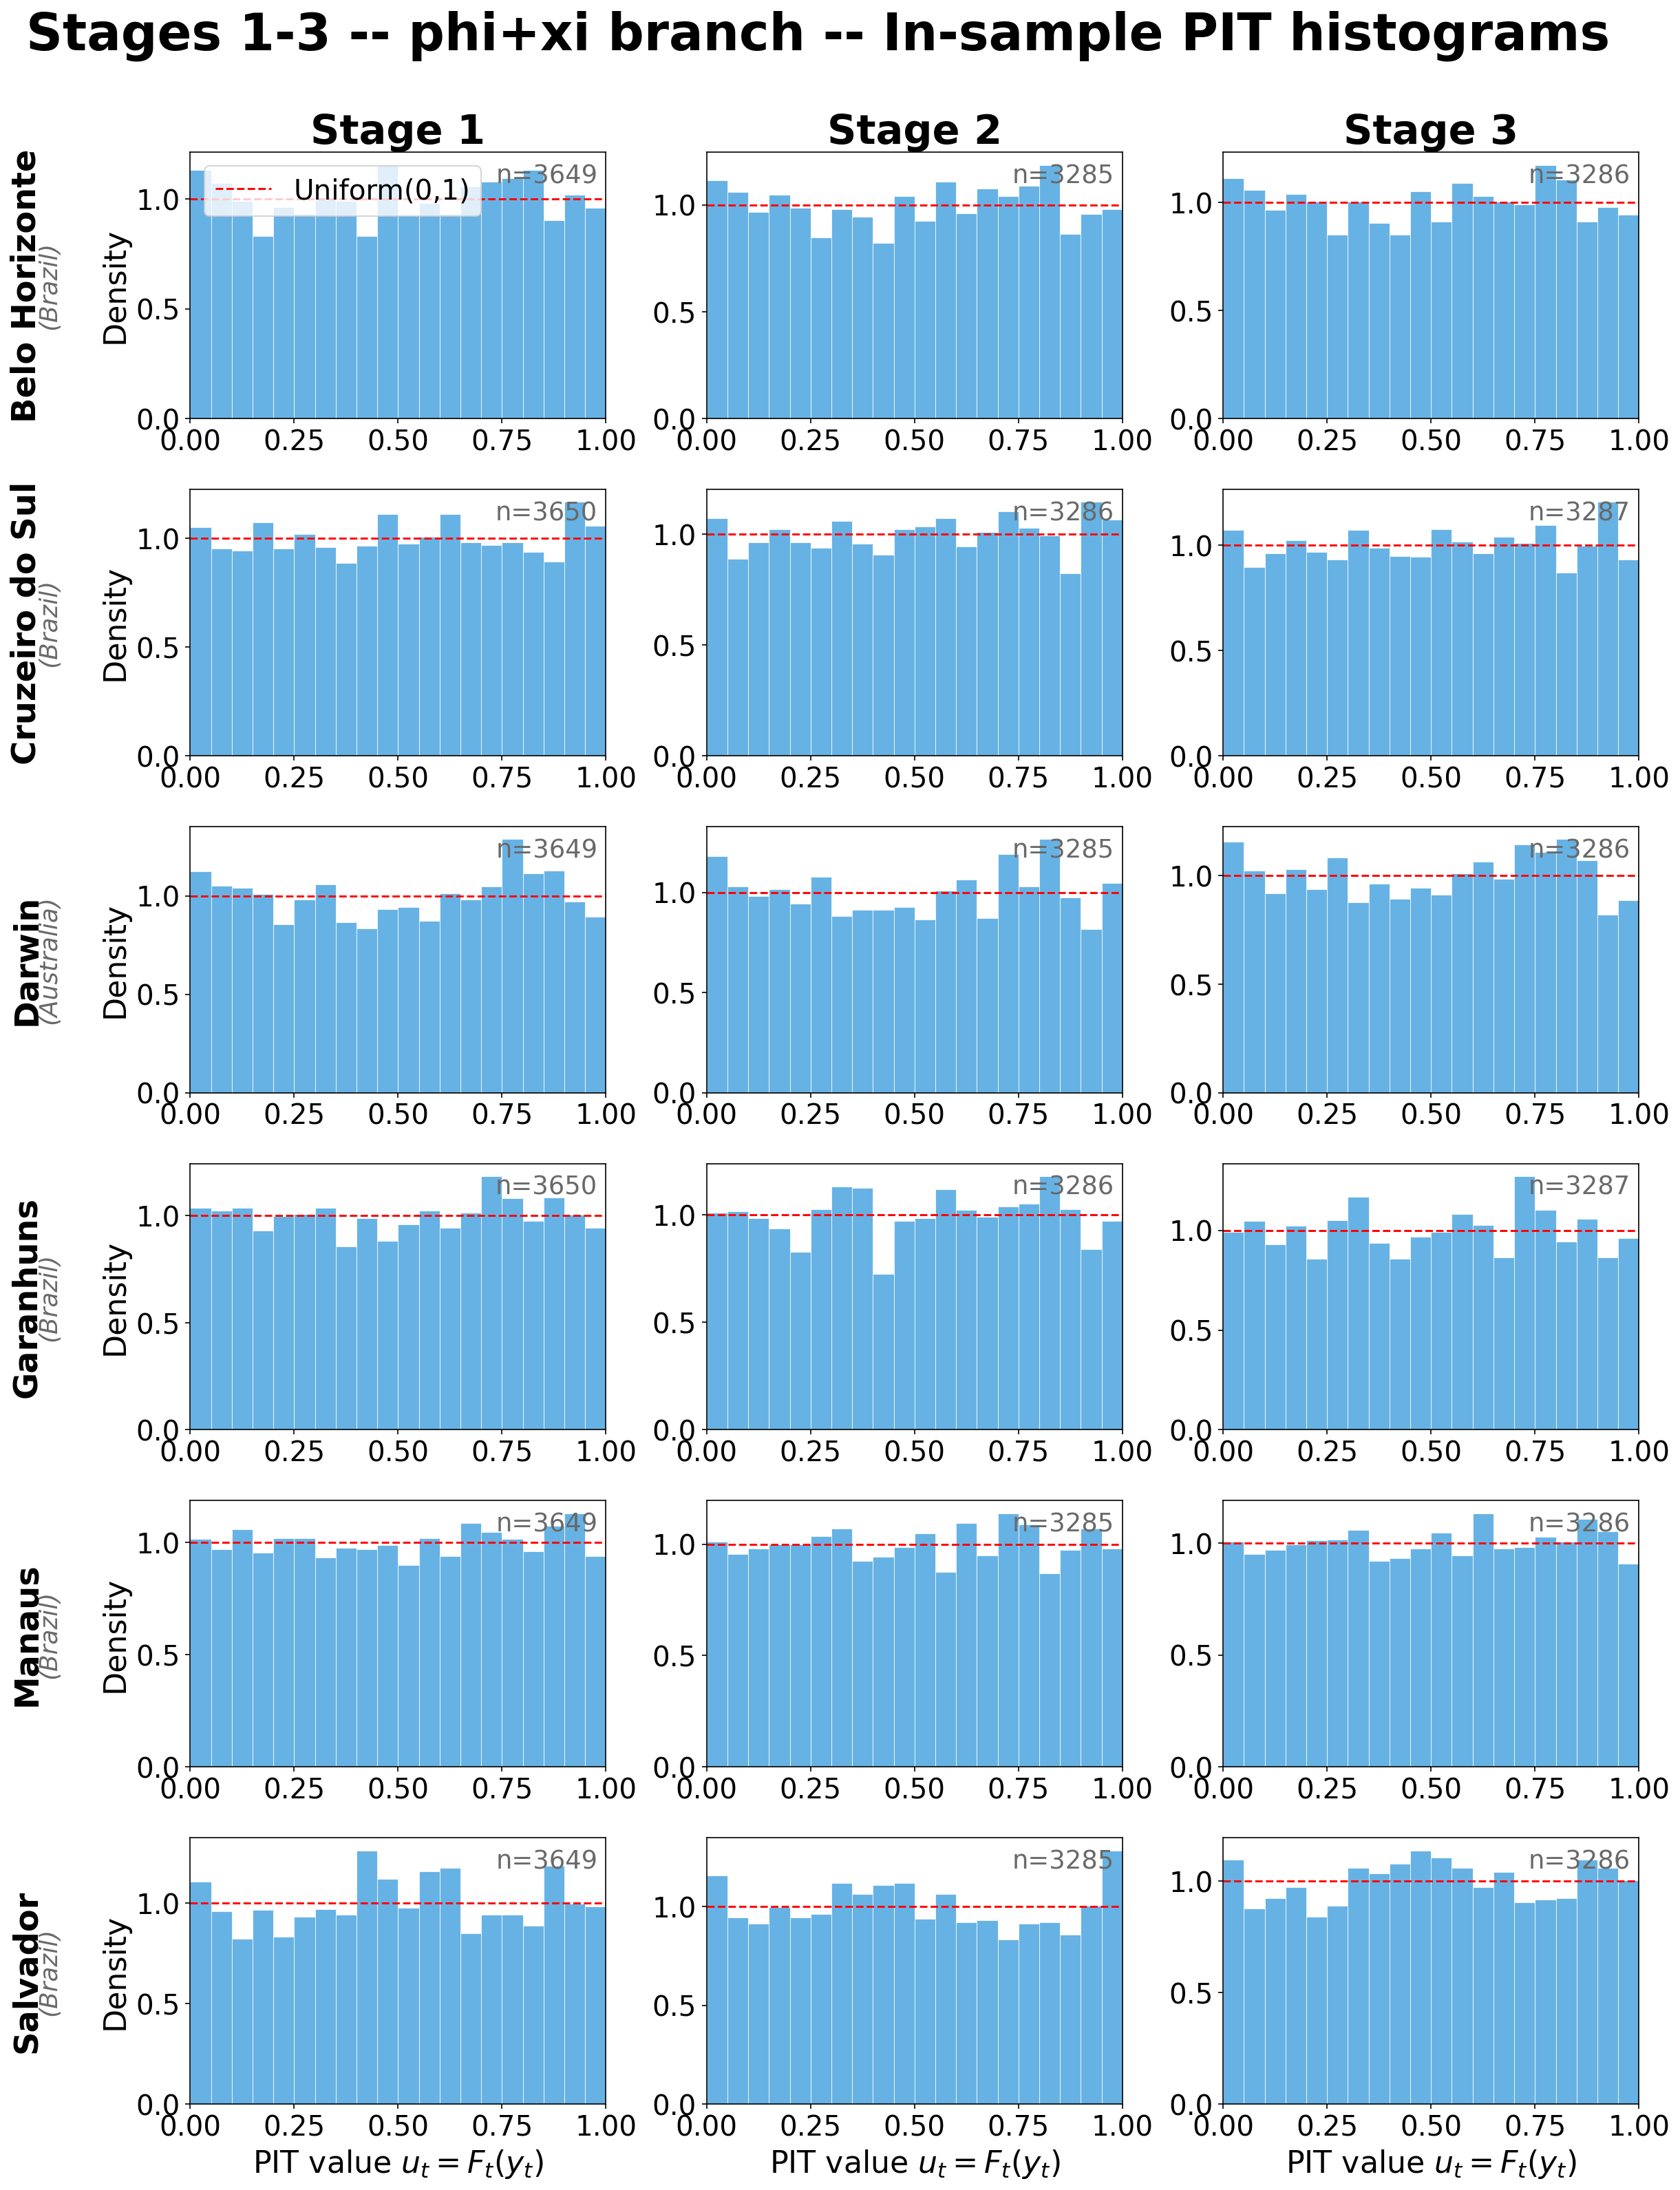

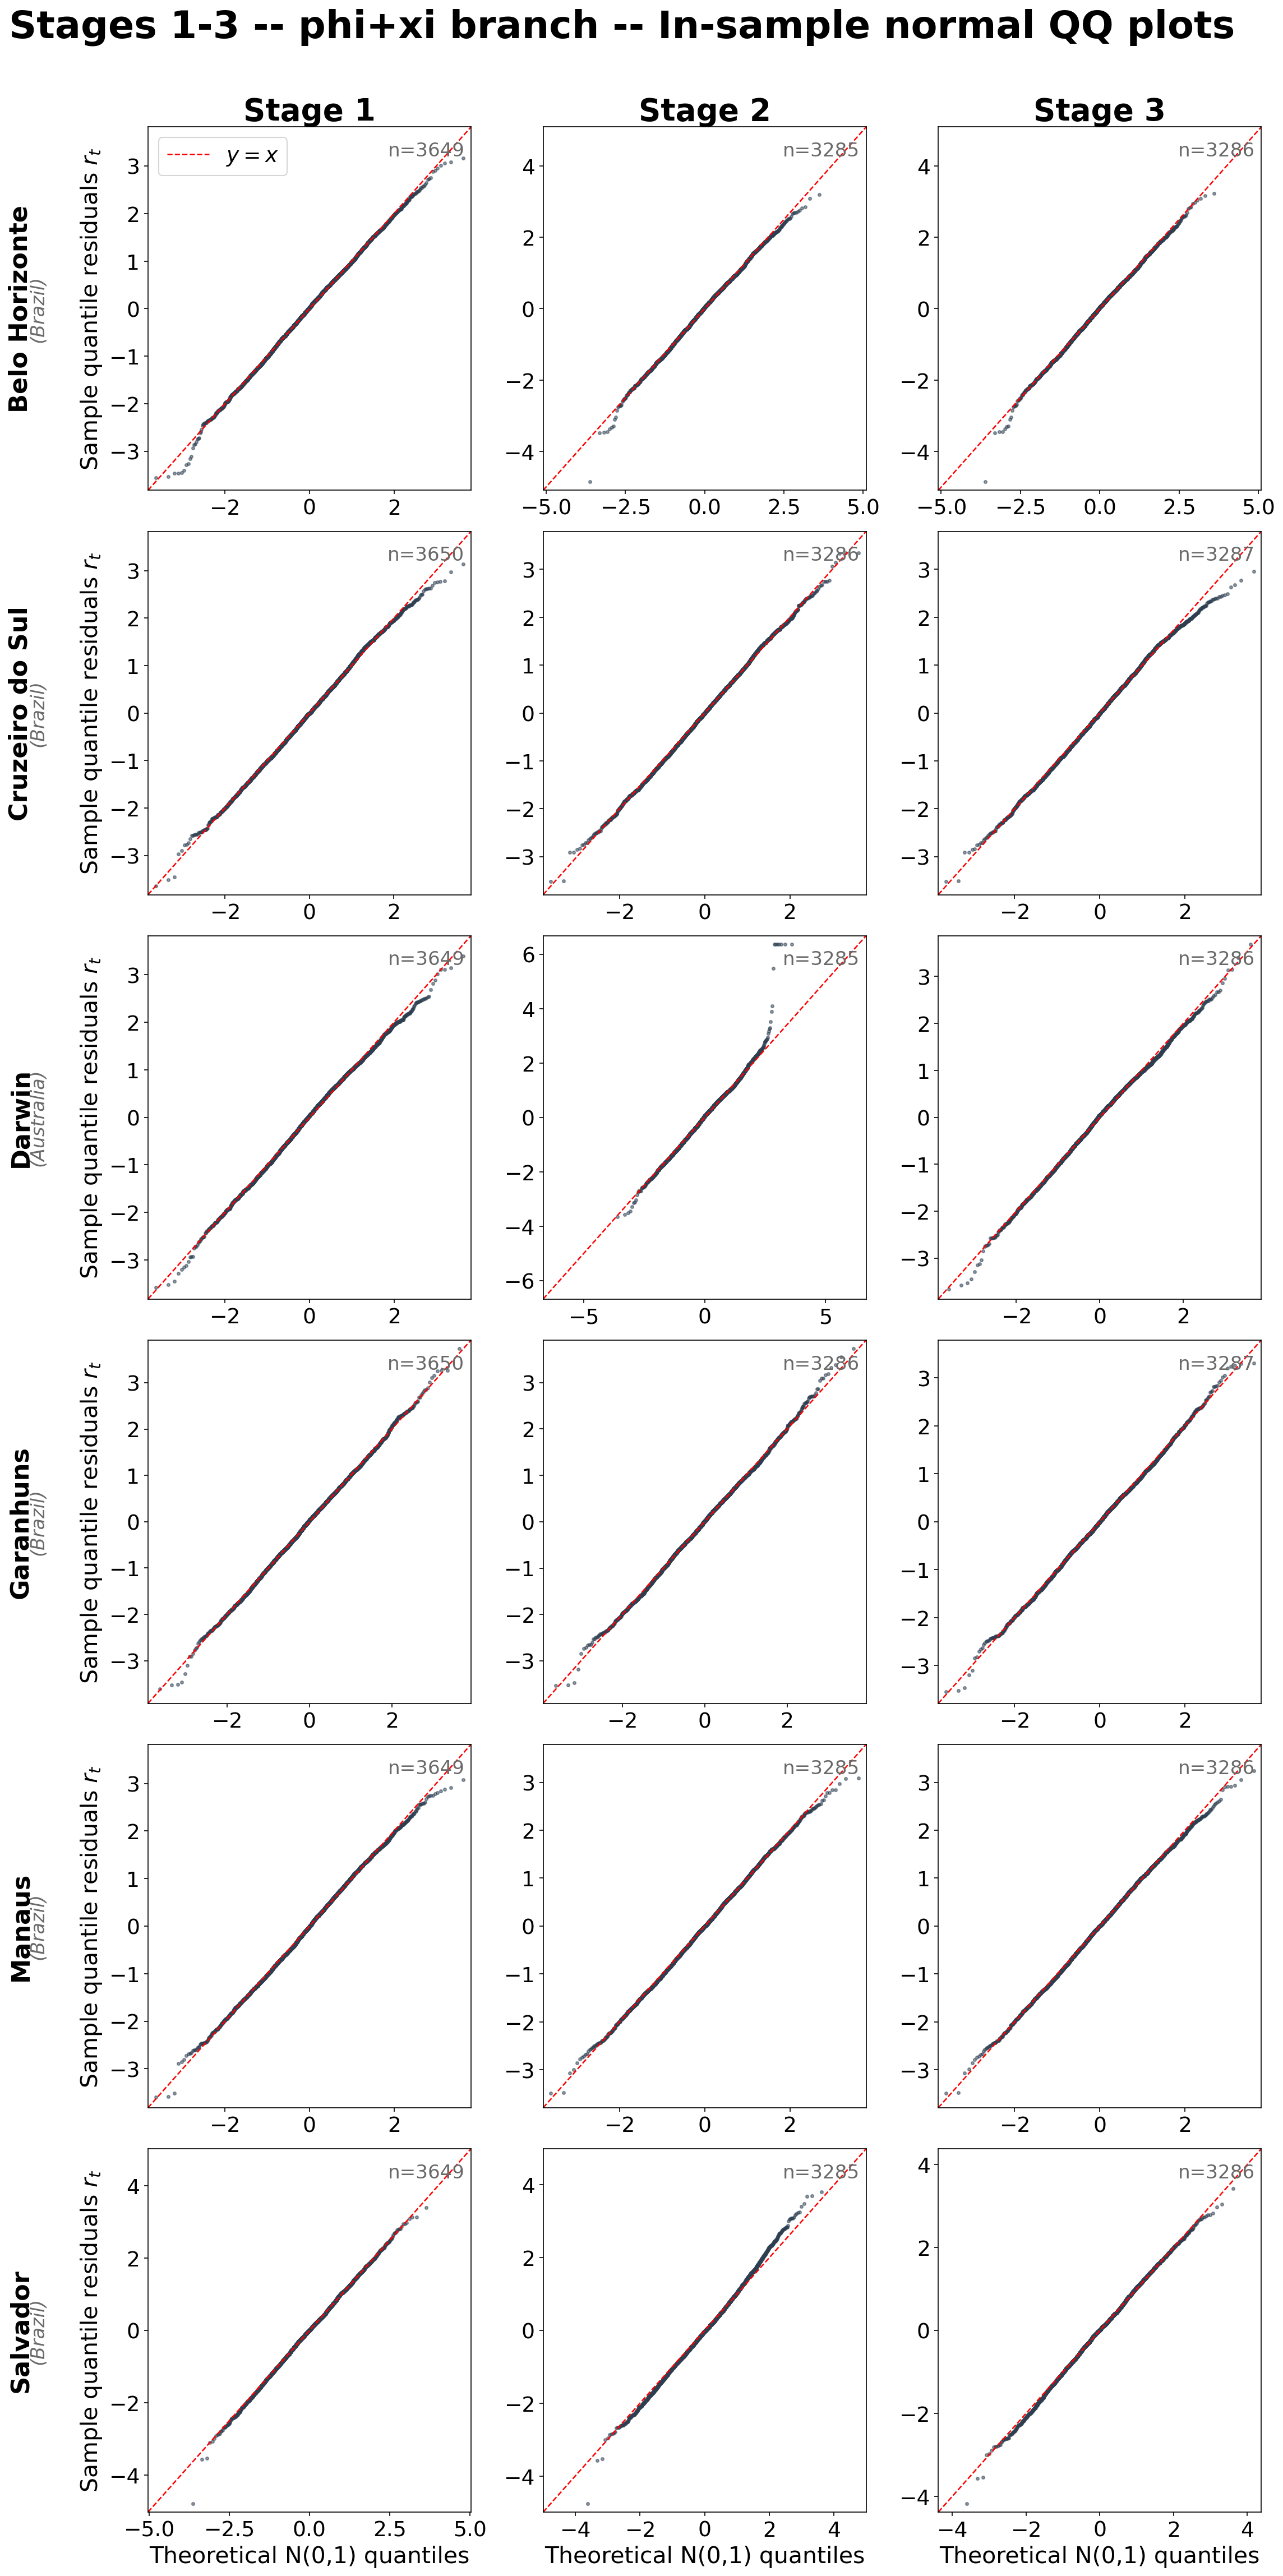

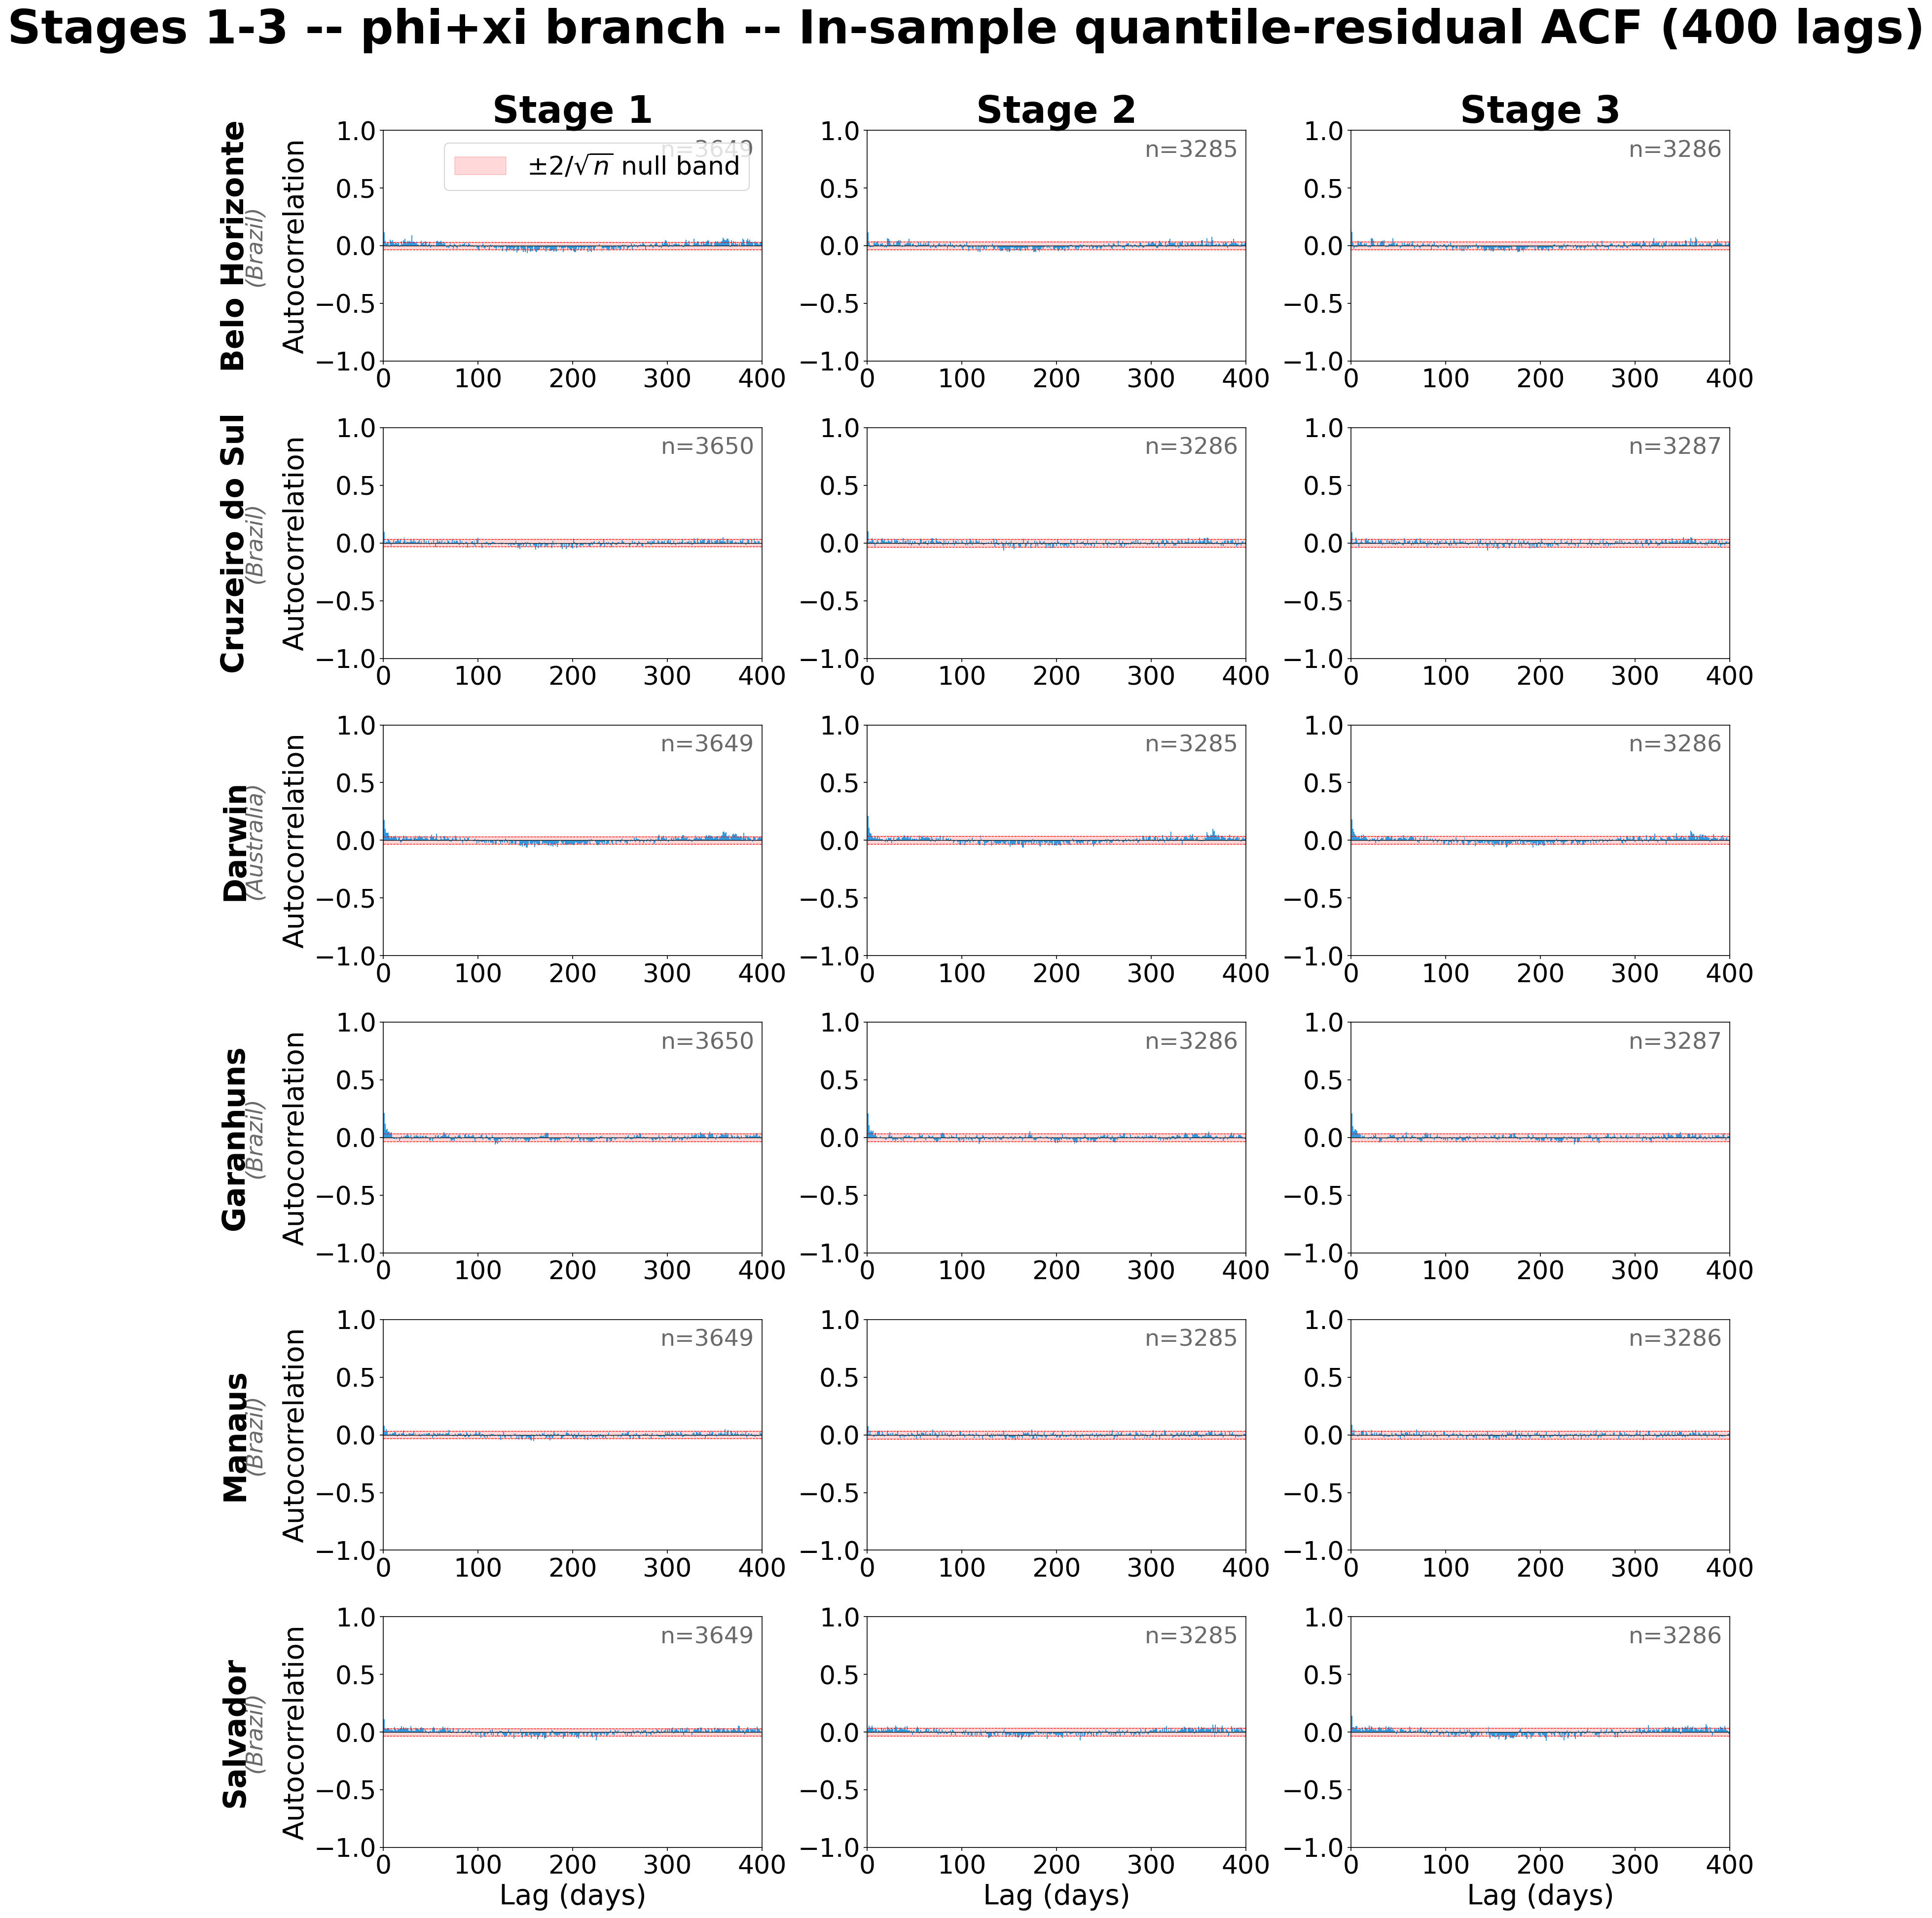


Stages 1-3 -- phi-only branch


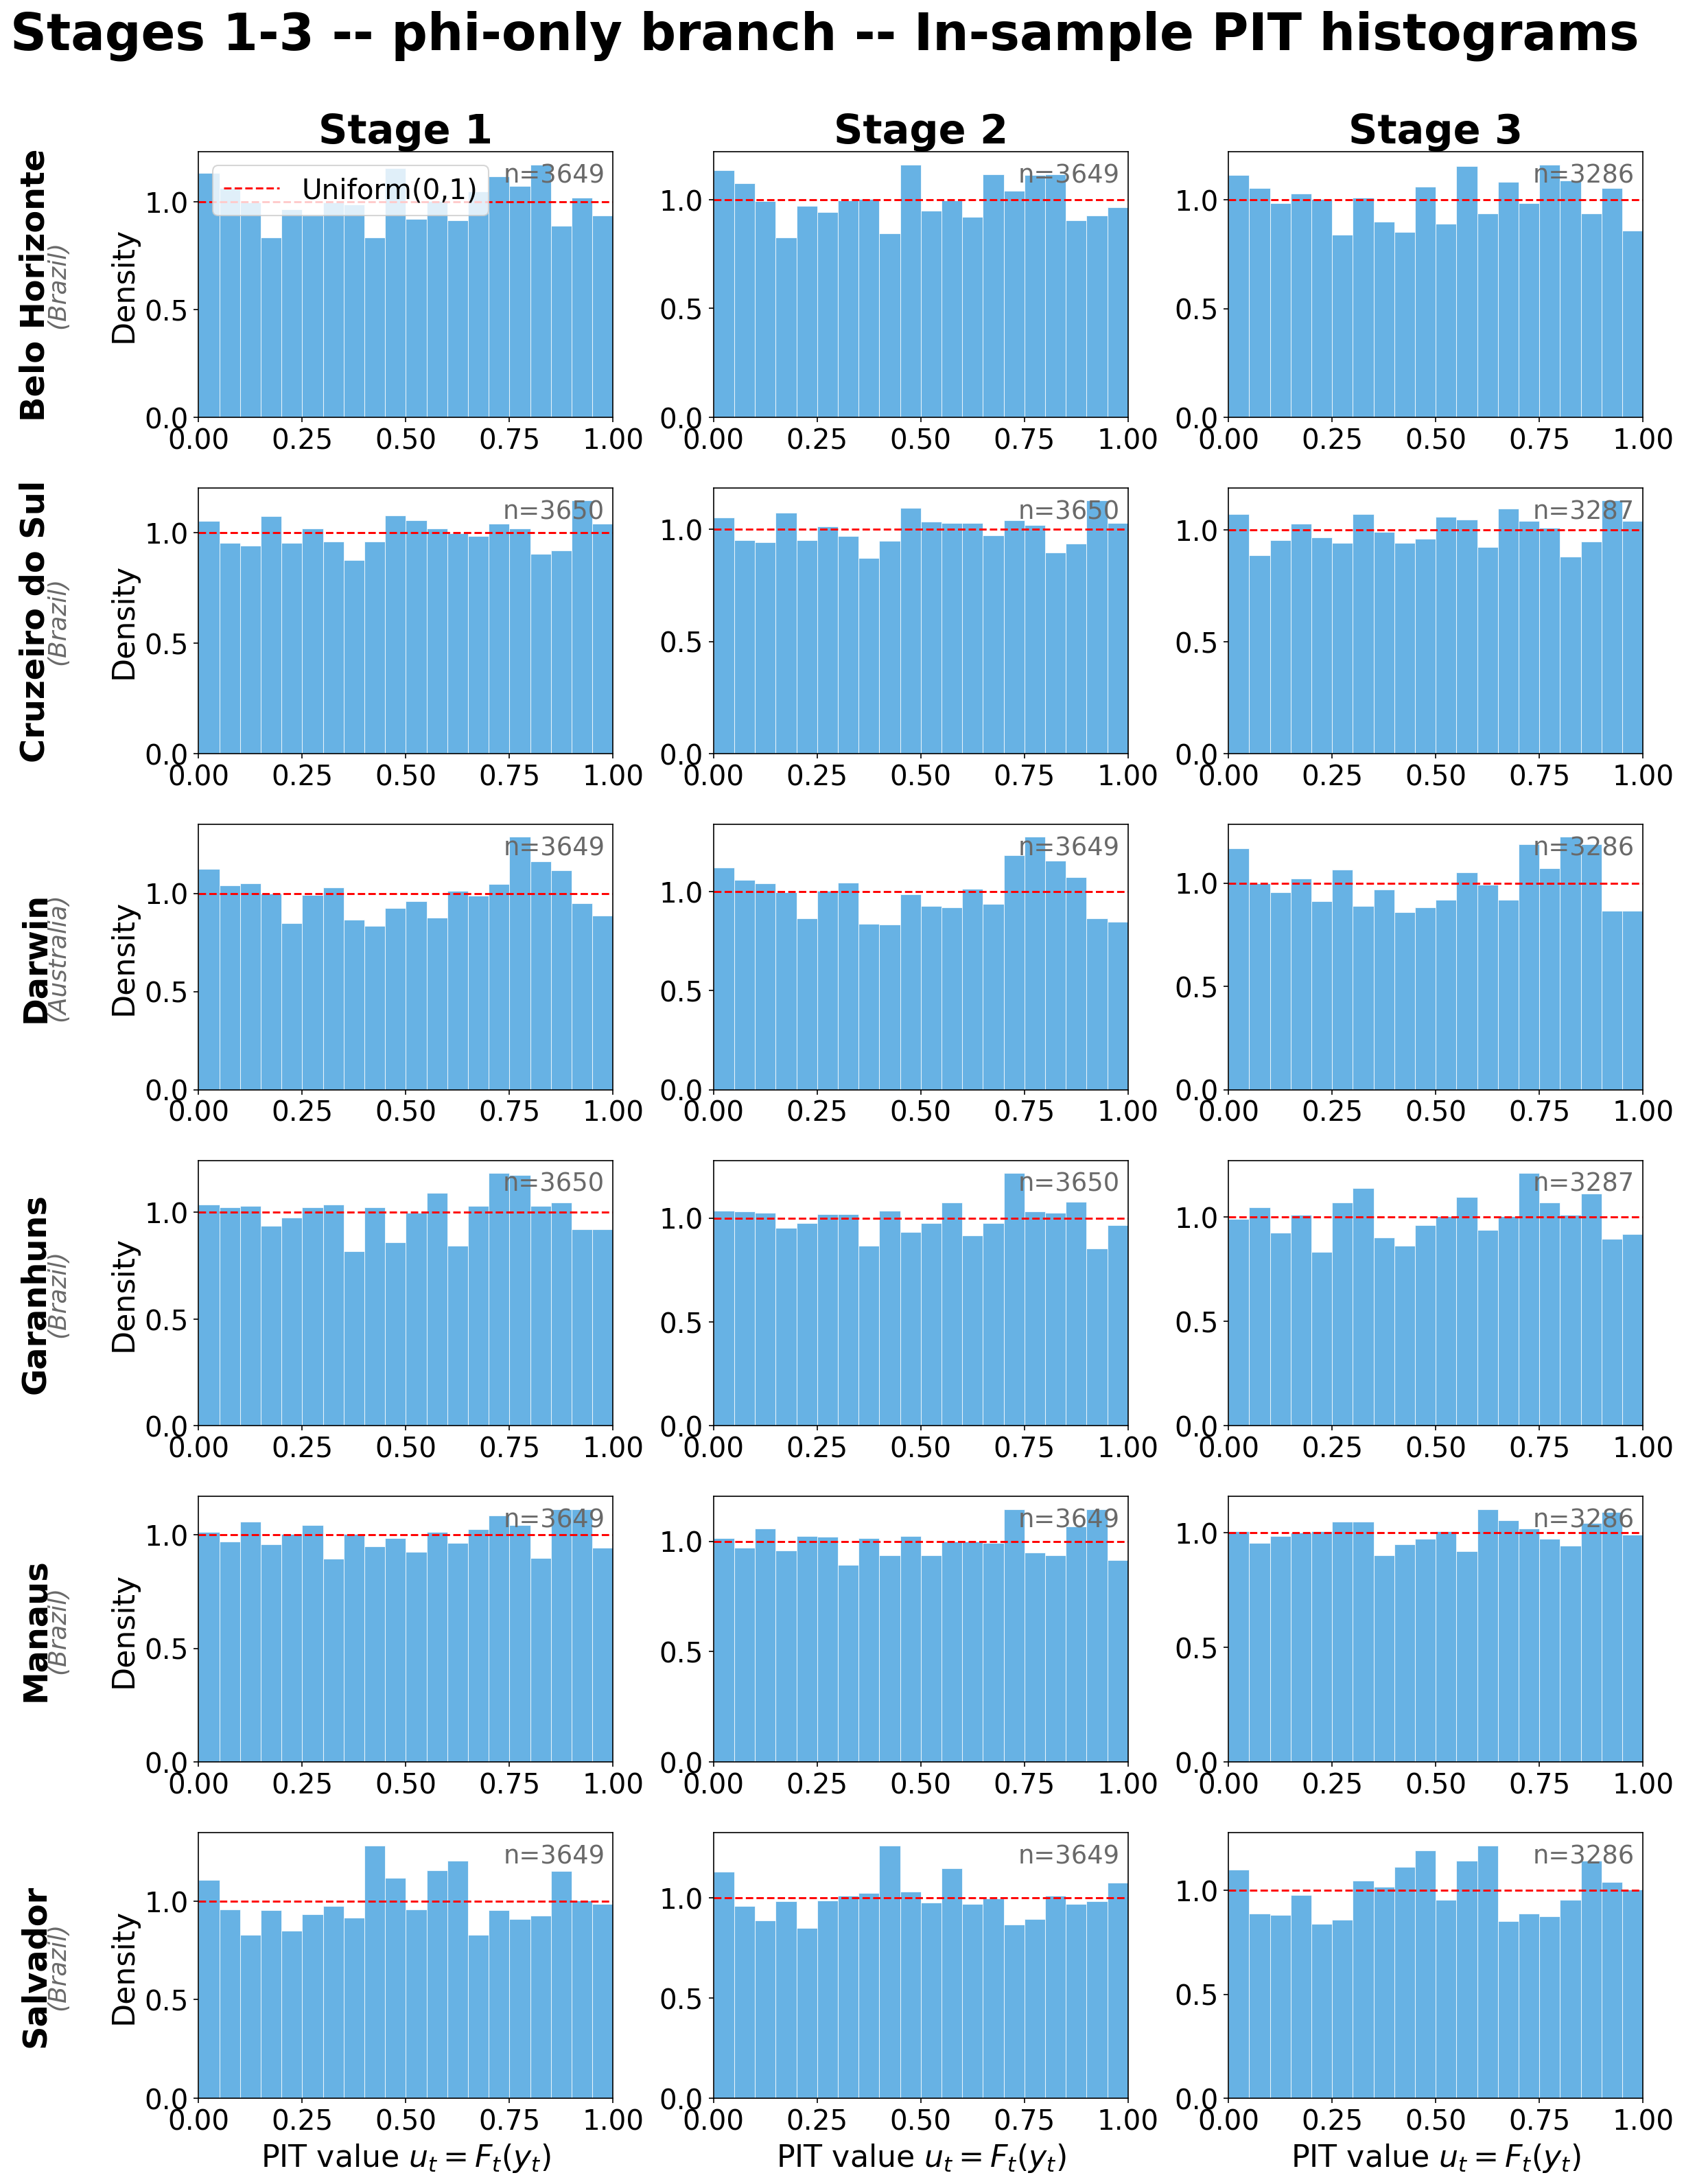

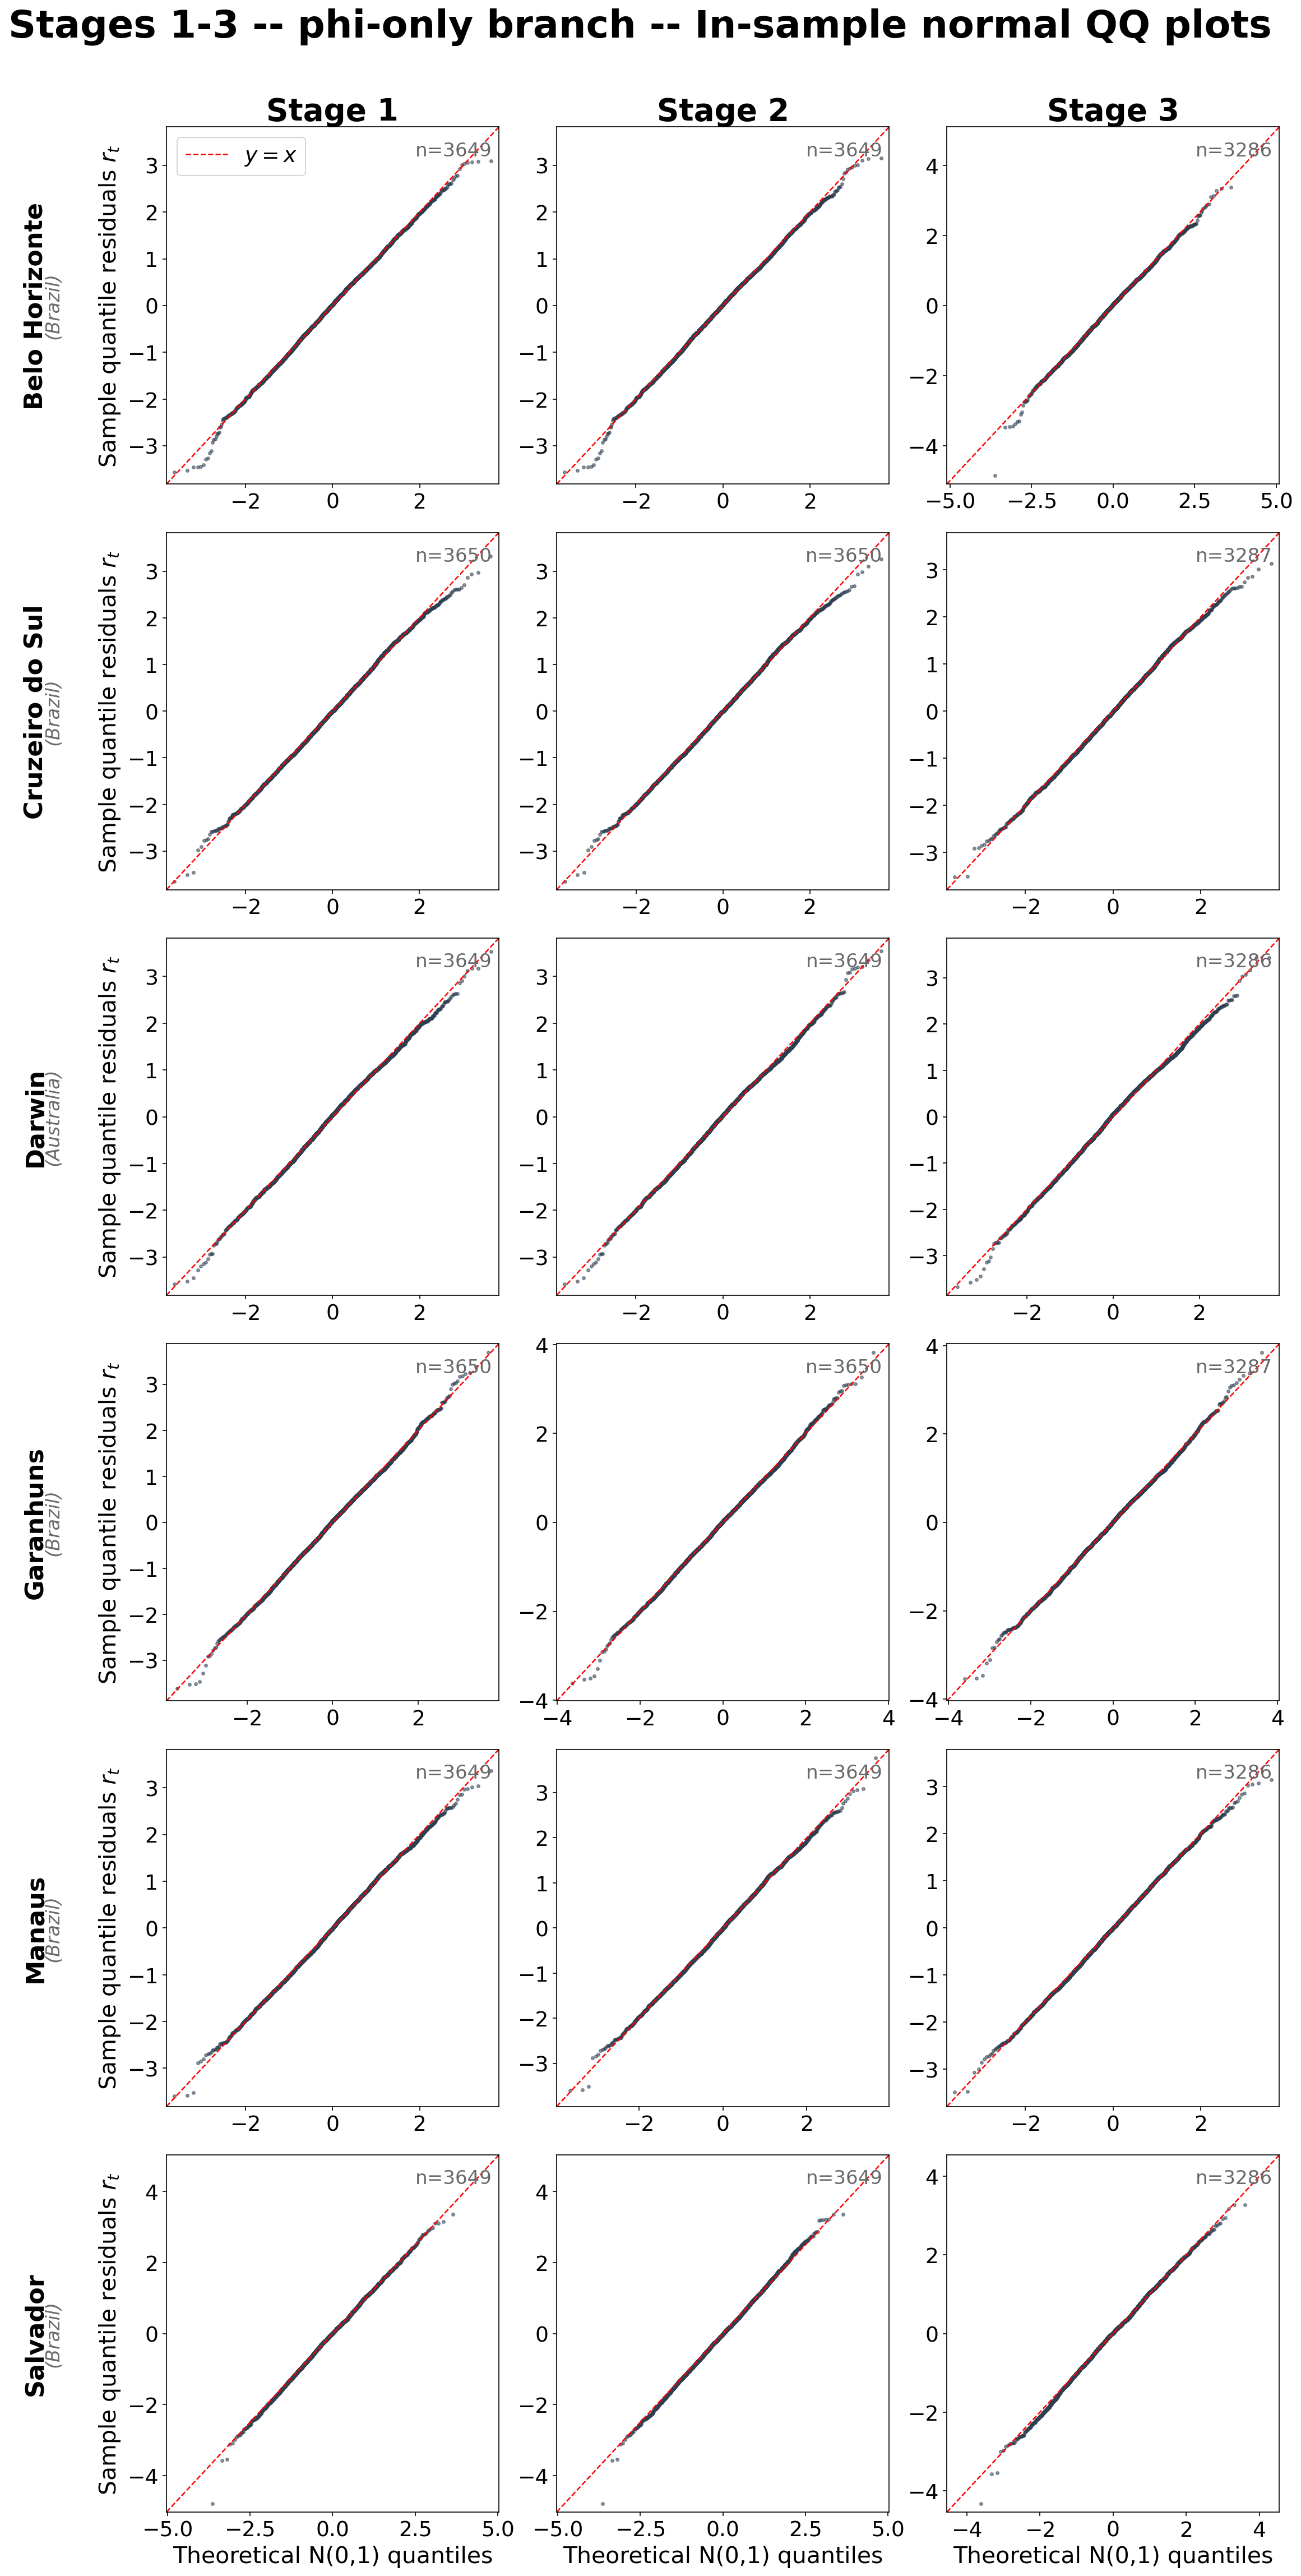

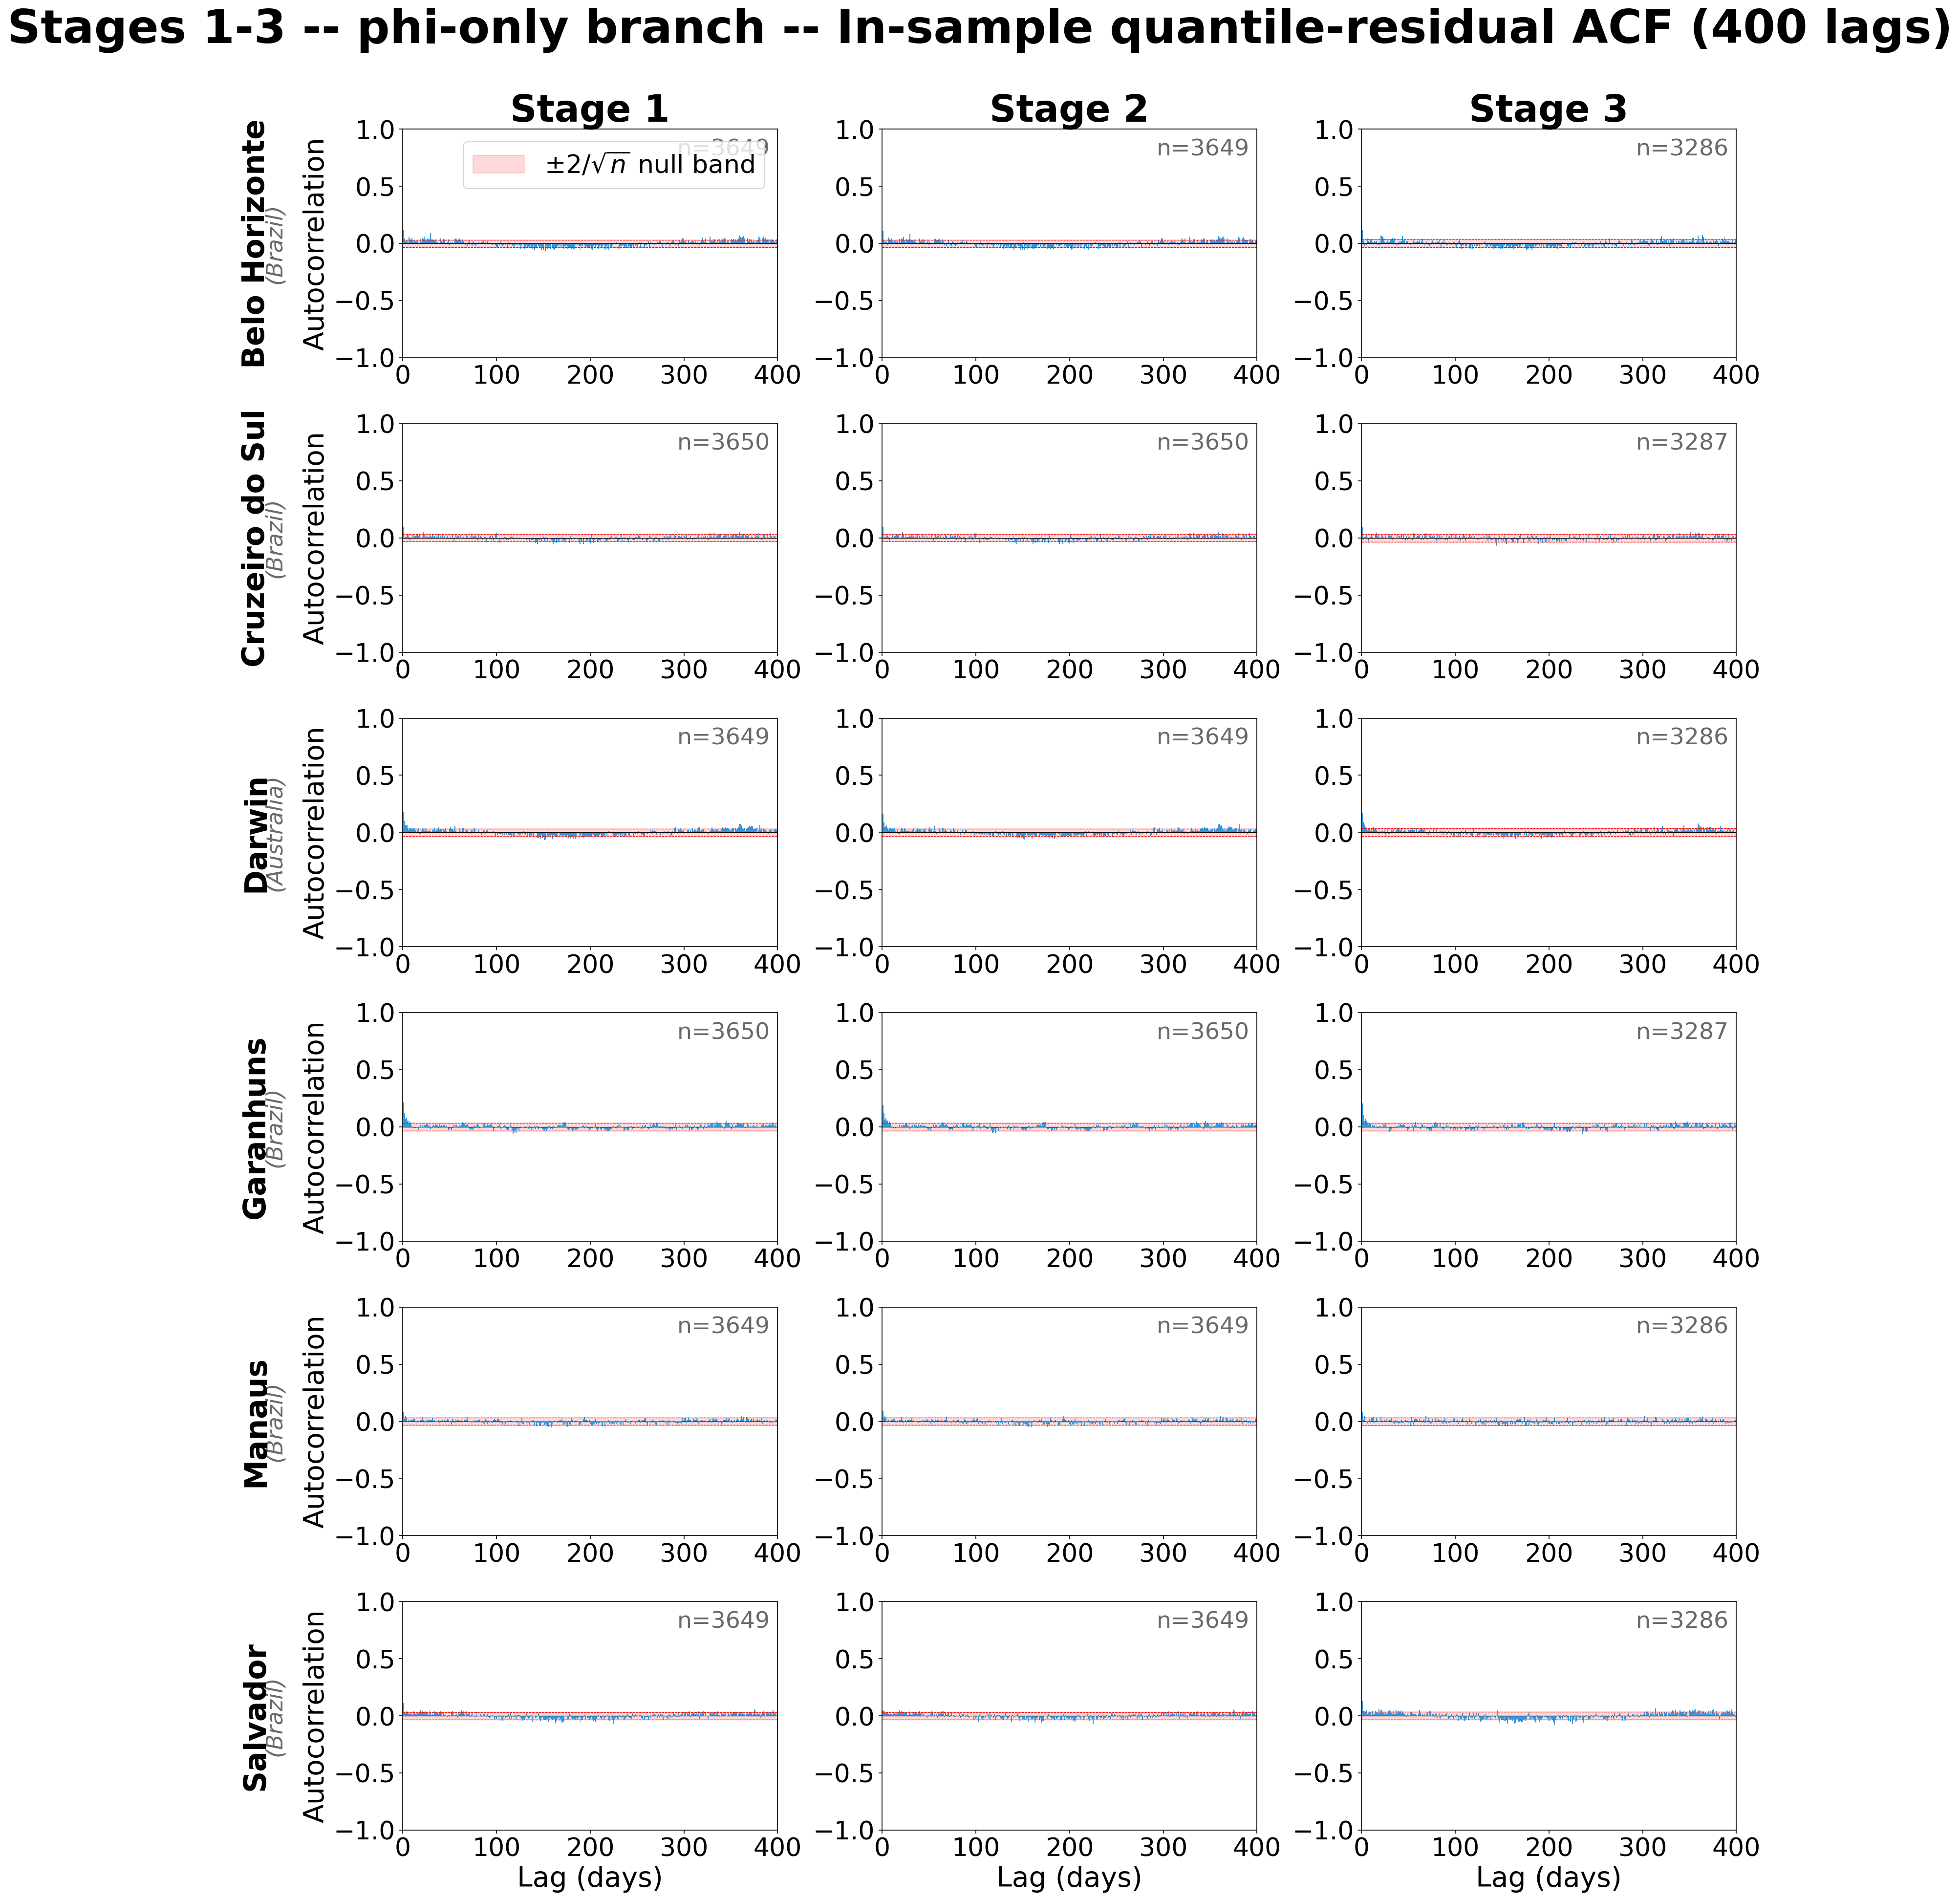


Stage 4 -- Tail-Sensitive xi Regime (composite)


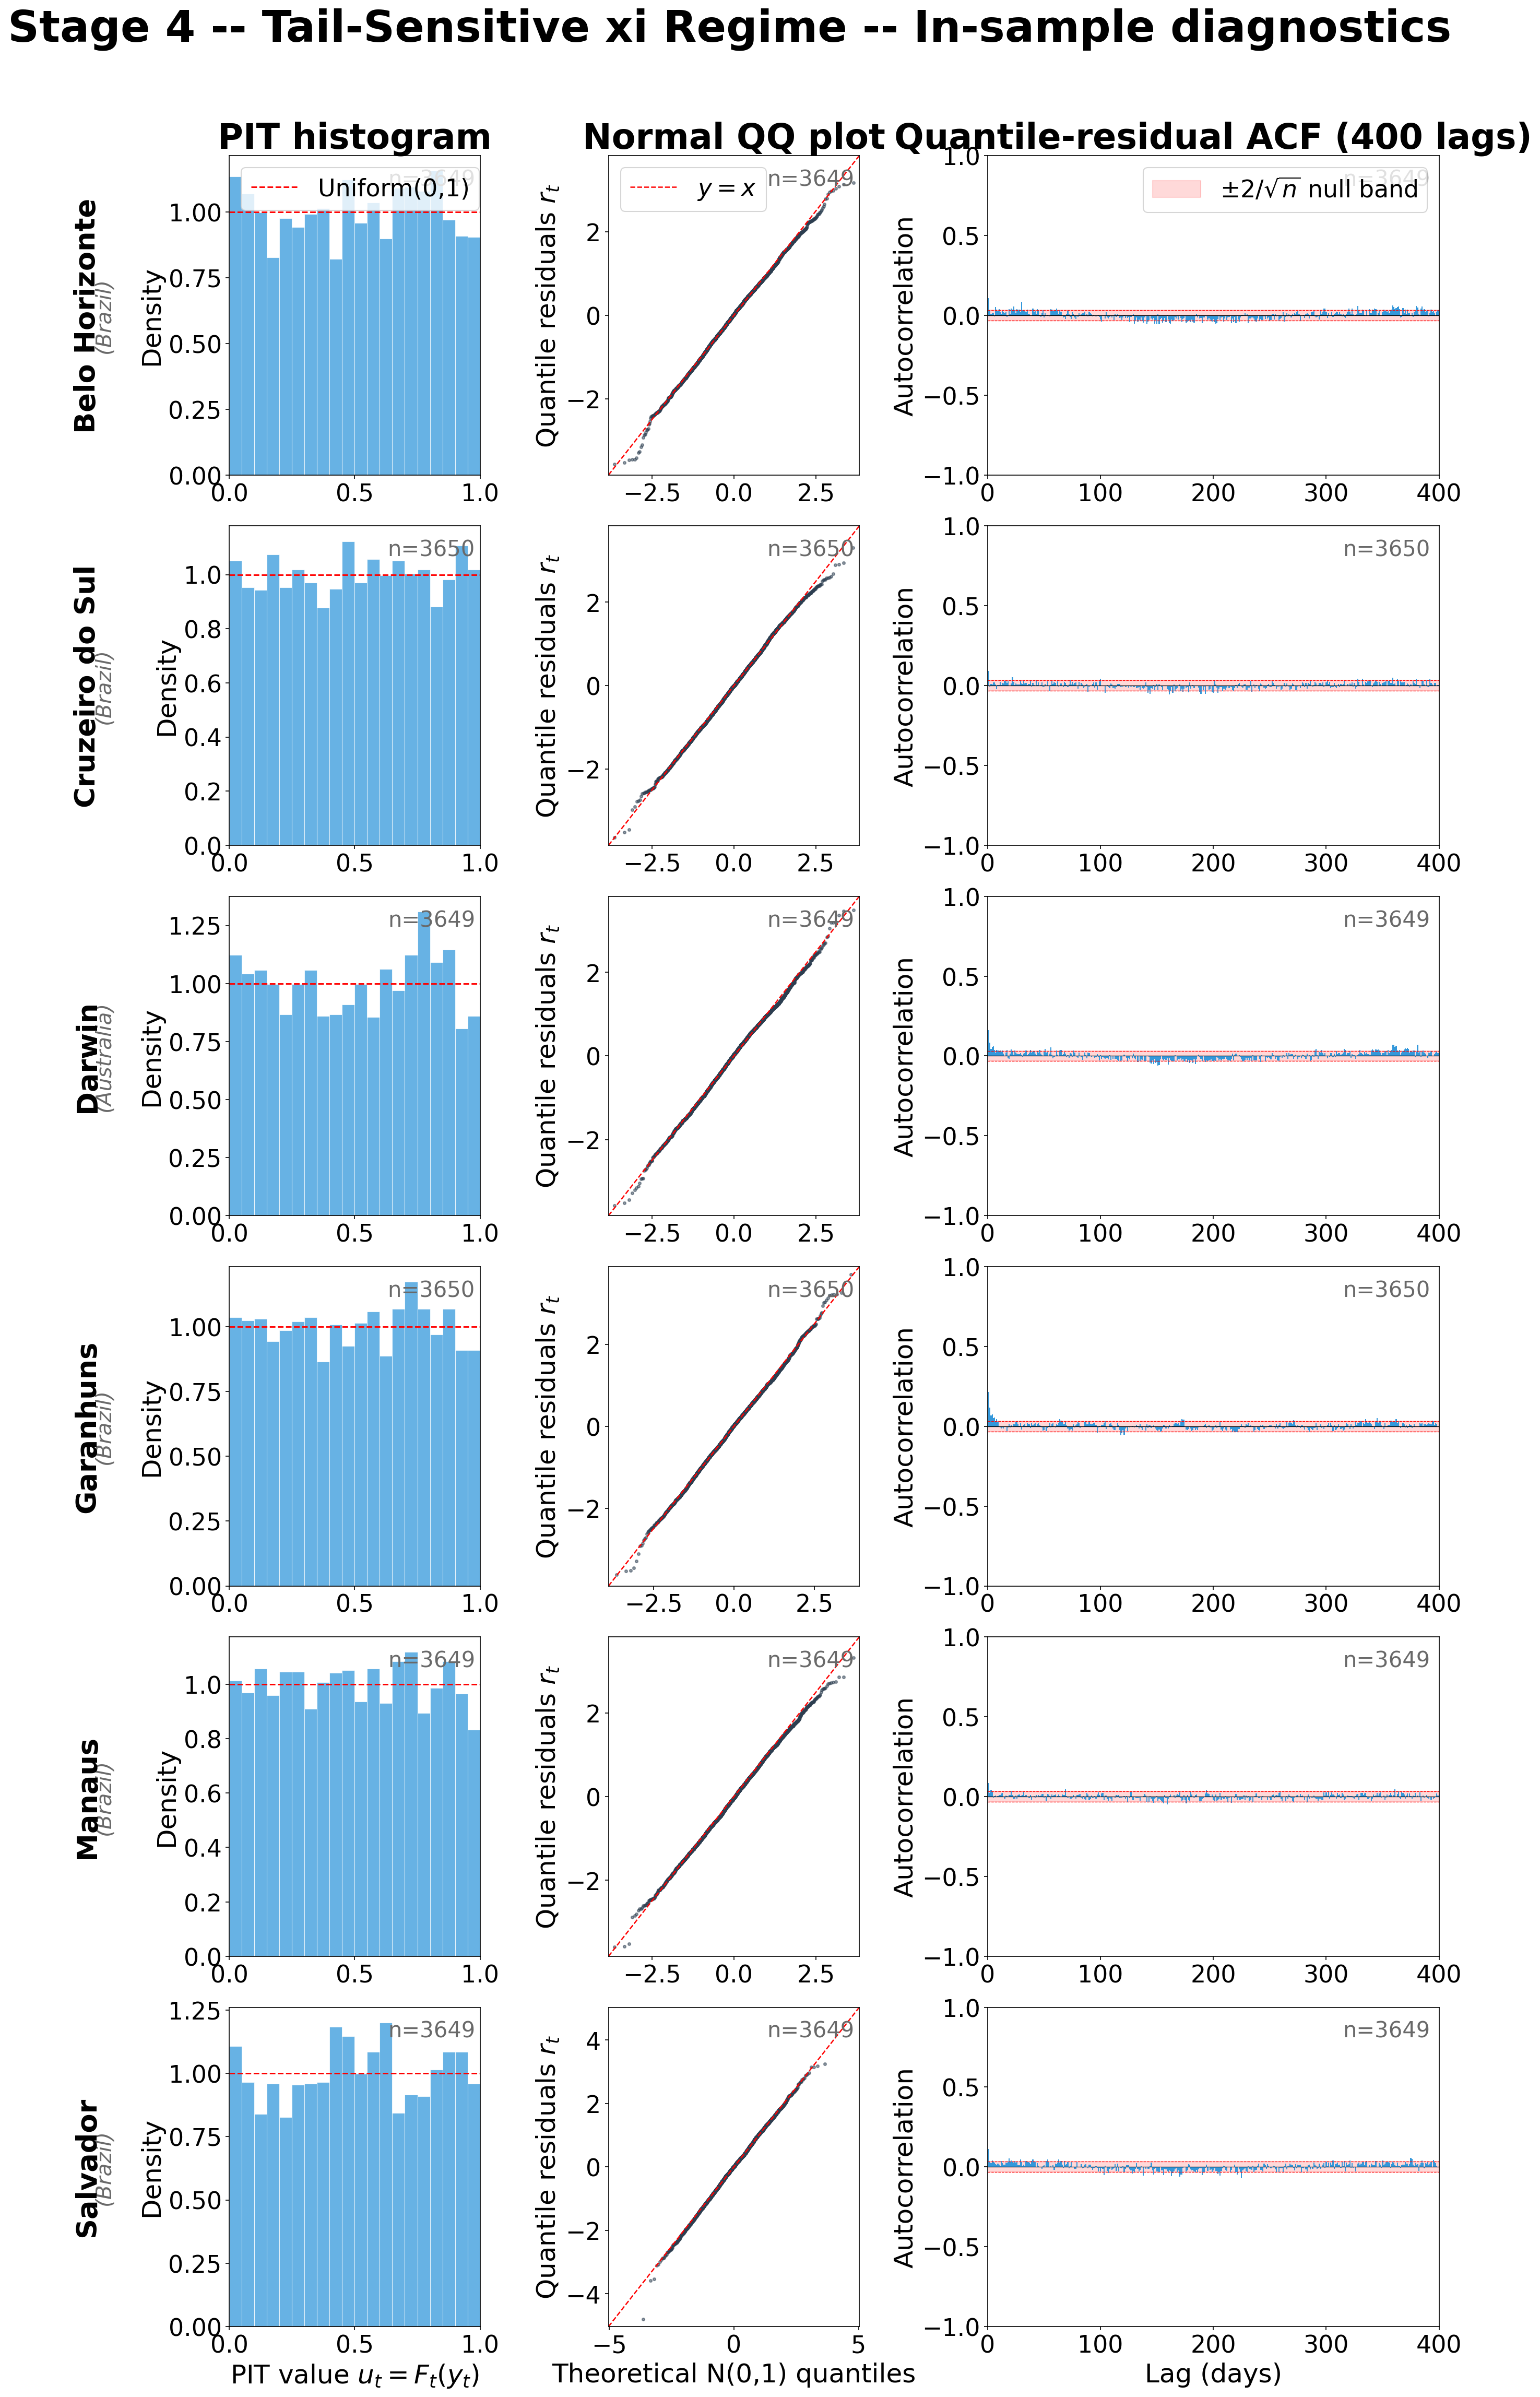


Generated 7 mosaic files in C:\Users\ilang\OneDrive\Documentos\Ilan\academia\dissertação\python attempt\FurtherTopics\reports\multi_location\mosaics


In [7]:
# =============================================================================
# Generate all mosaics
# =============================================================================
# Stages 1-3: one (rows=stage, columns=location) grid per chart type, per
# branch -- 3 chart types x 2 branches = 6 figures.
# Stage 4: one composite (rows=location, columns=[PIT, QQ, ACF]) figure.
#
# Every call below passes target_print_width_in / base_print_pt from the
# "Figure design settings" cell -- that is the only cell to edit for font
# size, not this one. location_names / location_countries (built in the
# Configuration cell) draw each row's short name and "(Country)" subtitle.
generated_files = []

for branch in BRANCHES:
    print(f"\n{'=' * 70}\nStages 1-3 -- {BRANCH_LABELS[branch]}\n{'=' * 70}")

    pit_grid, qr_grid, model_id_grid = compute_stages_1to3_grid(
        branch=branch, location_data=location_data, fig_cache_dir=FIG_CACHE_DIR,
    )

    fig = stage_pit_grid_mosaic(
        pit_grid, STAGE_ROW_LABELS, STAGES_1TO3, LOCATION_DISPLAY_NAMES,
        suptitle=stage1to3_title("PIT histograms", branch), bins=PIT_BINS,
        target_print_width_in=TARGET_PRINT_WIDTH_IN, base_print_pt=BASE_PRINT_PT,
        location_names=LOCATION_NAMES, location_countries=LOCATION_COUNTRIES,
    )
    generated_files.append(save_mosaic(fig, stage1to3_slug("pit", branch)))

    fig = stage_qq_grid_mosaic(
        qr_grid, STAGE_ROW_LABELS, STAGES_1TO3, LOCATION_DISPLAY_NAMES,
        suptitle=stage1to3_title("normal QQ plots", branch),
        target_print_width_in=TARGET_PRINT_WIDTH_IN, base_print_pt=BASE_PRINT_PT,
        location_names=LOCATION_NAMES, location_countries=LOCATION_COUNTRIES,
    )
    generated_files.append(save_mosaic(fig, stage1to3_slug("qq", branch)))

    fig = stage_acf_grid_mosaic(
        qr_grid, STAGE_ROW_LABELS, STAGES_1TO3, LOCATION_DISPLAY_NAMES,
        suptitle=stage1to3_title(f"quantile-residual ACF ({ACF_N_LAGS} lags)", branch),
        n_lags=ACF_N_LAGS,
        target_print_width_in=TARGET_PRINT_WIDTH_IN, base_print_pt=BASE_PRINT_PT,
        location_names=LOCATION_NAMES, location_countries=LOCATION_COUNTRIES,
    )
    generated_files.append(save_mosaic(fig, stage1to3_slug("acf400", branch)))

print(f"\n{'=' * 70}\nStage 4 -- Tail-Sensitive xi Regime (composite)\n{'=' * 70}")

pit_by_loc, qr_by_loc, model_id_by_loc = compute_stage_branch_diagnostics(
    stage=4, branch=None, location_data=location_data, fig_cache_dir=FIG_CACHE_DIR,
)
fig = stage4_composite_mosaic(
    pit_by_loc, qr_by_loc,
    suptitle=f"{STAGE_LABELS[4]} -- In-sample diagnostics",
    n_lags=ACF_N_LAGS, bins=PIT_BINS,
    target_print_width_in=TARGET_PRINT_WIDTH_IN, base_print_pt=BASE_PRINT_PT,
    location_names=LOCATION_NAMES, location_countries=LOCATION_COUNTRIES,
)
generated_files.append(save_mosaic(fig, "stage4_composite"))

print(f"\nGenerated {len(generated_files)} mosaic files in {MOSAICS_DIR}")

In [8]:
# =============================================================================
# Save a file index for the generated mosaics
# =============================================================================
index_df = pd.DataFrame({"file": [p.name for p in generated_files]})
index_df.to_csv(TABLES_DIR / "mosaic_file_index.csv", index=False)
index_df


,file
0,stage1to3_pit_phi_xi.png
1,stage1to3_qq_phi_xi.png
2,stage1to3_acf400_phi_xi.png
3,stage1to3_pit_phi_only.png
4,stage1to3_qq_phi_only.png
5,stage1to3_acf400_phi_only.png
6,stage4_composite.png


## How to change the figure design

**Font size / readability in the PDF:** edit the "Figure design settings"
cell near the top (`TARGET_PRINT_WIDTH_IN`, `BASE_PRINT_PT`). That is the
one place this needs to change — see that cell for why.

**Row labels (location name + country):** each row is labelled with the
location's name and a "(Country)" subtitle (`LOCATION_NAMES` /
`LOCATION_COUNTRIES`, built in the Configuration cell from
`data/station_loader.py`'s `mosaic_name()` and the `STATION_REGISTRY`
`"country"` field) — edit the registry there to rename a location or
change its country, not this notebook. `diagnostics/plots.py`'s
`_row_label` draws the name and country as two side-by-side rotated
columns rather than stacked lines (see that function's docstring for why)
so no row-height change is needed for a longer or shorter name.

Everything else about how a mosaic **looks** lives in
`diagnostics/plots.py` (`stage_pit_grid_mosaic`, `stage_qq_grid_mosaic`,
`stage_acf_grid_mosaic`, `stage4_composite_mosaic`, and the three shared
single-panel drawers `_draw_pit_panel` / `_draw_qq_panel` /
`_draw_acf_panel` they all call); everything about **which models** it
looks at lives in `diagnostics/multilocation_mosaics.py`. This notebook
only wires the two together and saves the results, per
`docs/EXECUTION.md` Sec 23 ("notebooks should orchestrate ... not contain
model implementations").

Other quick knobs, without touching `diagnostics/plots.py`:

- `STAGES_1TO3`, `BRANCHES`, `LOCATION_DISPLAY_NAMES` — row/column order
  for the Stages-1-3 grids. Reordering these reorders the grid.
- `STAGE_ROW_LABELS` — the short text shown in the row-label column.
- `PIT_BINS`, `ACF_N_LAGS`, `DPI` — set in the Configuration cell above.

Deeper style changes (colors, marker size, line widths, per-panel figure
size in inches, the confidence-band shading) are parameters or literal
constants inside the four mosaic functions and the three `_draw_*_panel`
helpers in `diagnostics/plots.py`. Because every chart type's statistics
are defined exactly once in its `_draw_*_panel` function and reused by
both the Stages-1-3 grids and the Stage-4 composite, changing (say) the
PIT histogram's color only requires editing `_draw_pit_panel` — it does
not need to be repeated anywhere else.

To add a location: register it in `STATION_REGISTRY`
(`data/station_loader.py`) — including its `"country"` and, if needed, a
`"mosaic_name"` override — and add it to `LOCATIONS` in
`diagnostics/multilocation_mosaics.py` once its Stage 1-4 artifacts exist.


## Output Index

- `reports/multi_location/mosaics/*.png` / `*.pdf` — **7 mosaic figures**:
  - `stage1to3_pit_phi_xi`, `stage1to3_qq_phi_xi`, `stage1to3_acf400_phi_xi`
  - `stage1to3_pit_phi_only`, `stage1to3_qq_phi_only`, `stage1to3_acf400_phi_only`
  - `stage4_composite`
- `reports/multi_location/mosaics/tables/stage_branch_winners.csv` — which
  saved `model_id` was diagnosed in every mosaic cell.
- `reports/multi_location/mosaics/tables/mosaic_file_index.csv` — list of
  every generated mosaic file.
- `reports/multi_location/mosaics/_individual_model_cache/` — the
  individual per-model PIT/QQ/ACF PNGs that
  `_compute_is_diagnostics_for_winner` always saves as a side effect (kept
  isolated from `reports/multi_location/figures/`, the main report's own
  cache).
